#Introduccion

Este informe analiza los datos de clientes de TelecomX LATAM para identificar los factores que influyen en la cancelación (churn) de servicios. Los datos provienen del archivo "datos_limpiados.csv", que contiene información sobre 7,032 clientes, incluyendo variables demográficas, de servicio y financieras. El churn afecta aproximadamente al 26.58% de los clientes (media de la variable Churn).
El análisis se basa en:

Variables seleccionadas: Género, edad (SeniorCitizen), estado civil (Partner), dependientes, antigüedad (tenure), servicios (PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies), tipo de contrato, facturación sin papel y método de pago, cargos mensuales y totales, y cuentas diarias.
Modelos de machine learning: Se evaluaron Logistic Regression, Random Forest, Gradient Boosting  para predecir churn. Estos modelos ayudan a cuantificar la importancia de las variables y evaluar el rendimiento predictivo.

El objetivo es destacar los factores clave de churn y proponer estrategias de retención. El análisis se realizó utilizando Python con bibliotecas como pandas, scikit-learn y matplotlib para procesamiento y modelado.

#Importacion de Datos

In [165]:
import pandas as pd

df = pd.read_json('/content/datos_limpiados.json')

df.drop(columns='customerID',inplace=True)
df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']] = df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].replace('No internet service',0)
df['MultipleLines']=df['MultipleLines'].replace('No phone service',0)
df['gender']=df['gender'].replace('Male',0)
df['gender']=df['gender'].replace('Female',1)


/tmp/ipykernel_459/3154146476.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']] = df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].replace('No internet service',0)
/tmp/ipykernel_459/3154146476.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MultipleLines']=df['MultipleLines'].replace('No phone service',0)
/tmp/ipykernel_459/3154146476.py:9: FutureWarning: Downcastin

In [166]:
columnas_str = ['InternetService','PaymentMethod','Contract']

In [167]:
df[columnas_str] = df[columnas_str].astype(str)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   int64  
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   int64  
 10  OnlineBackup      7032 non-null   int64  
 11  DeviceProtection  7032 non-null   int64  
 12  TechSupport       7032 non-null   int64  
 13  StreamingTV       7032 non-null   int64  
 14  StreamingMovies   7032 non-null   int64  
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [169]:
df.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.131520
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,0.989670
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.600329
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.170641
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.314145
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.956003
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.906250


In [170]:
X = df.drop(columns='Churn')
y = df['Churn']

#Encoding

In [171]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [172]:
columnas = X.columns
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),['InternetService','PaymentMethod','Contract']),remainder='passthrough',sparse_threshold=0,force_int_remainder_cols=False)

In [173]:
X = one_hot.fit_transform(X)

In [174]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__InternetService_0',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year',
       'onehotencoder__Contract_Two year', 'remainder__gender',
       'remainder__SeniorCitizen', 'remainder__Partner',
       'remainder__Dependents', 'remainder__tenure',
       'remainder__PhoneService', 'remainder__MultipleLines',
       'remainder__OnlineSecurity', 'remainder__OnlineBackup',
       'remainder__DeviceProtection', 'remainder__TechSupport',
       'remainder__StreamingTV', 'remainder__StreamingMovies',
       'remainder__PaperlessBilling', 'remainder__Charges.Monthly',
       'remainder__Charges.Total', 'r

In [182]:
df_encoding = pd.DataFrame(X,columns = one_hot.get_feature_names_out(columnas))

In [183]:
y.value_counts()

,count
Churn,
0,5163
1,1869


#Balanceo de cuentas

In [184]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

In [185]:
oversample = SMOTE()

In [186]:
X_balanceada, y_balanceada = oversample.fit_resample(X, y)

In [187]:
y_balanceada.value_counts()

,count
Churn,
0,5163
1,5163


# Matriz correlacion

In [189]:
df_encoding['Churn']= y

In [195]:
df_encoding.corr()

,onehotencoder__InternetService_0,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,...,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Cuentas_Diarias,Churn
onehotencoder__InternetService_0,1.000000,-0.379912,-0.465736,-0.001094,0.001870,-0.284608,0.319694,-0.217824,0.038061,0.217542,...,-0.380990,-0.380151,-0.335695,-0.414951,-0.418450,-0.320592,-0.763191,-0.374878,-0.763191,0.019655
onehotencoder__InternetService_DSL,-0.379912,1.000000,-0.641636,0.024760,0.051222,-0.104293,0.042754,-0.065226,0.047300,0.030924,...,0.156765,0.145150,0.312183,0.014973,0.025623,-0.063390,-0.161368,-0.052190,-0.161368,0.002098
onehotencoder__InternetService_Fiber optic,-0.465736,-0.641636,1.000000,-0.022779,-0.050552,0.335763,-0.305984,0.243014,-0.076809,-0.209965,...,0.165940,0.176356,-0.020299,0.329744,0.322457,0.326470,0.787195,0.360769,0.787195,-0.018361
onehotencoder__PaymentMethod_Bank transfer (automatic),-0.001094,0.024760,-0.022779,1.000000,-0.278423,-0.377270,-0.288097,-0.180159,0.057629,0.155004,...,0.086942,0.083047,0.100472,0.046121,0.048755,-0.017469,0.042410,0.186119,0.042410,0.011851
onehotencoder__PaymentMethod_Credit card (automatic),0.001870,0.051222,-0.050552,-0.278423,1.000000,-0.373978,-0.285583,-0.204960,0.067590,0.174410,...,0.090455,0.111252,0.117024,0.040010,0.048398,-0.013726,0.030055,0.182663,0.030055,0.006509
onehotencoder__PaymentMethod_Electronic check,-0.284608,-0.104293,0.335763,-0.377270,-0.373978,1.000000,-0.386971,0.330879,-0.109546,-0.281147,...,-0.000364,-0.003308,-0.114807,0.144747,0.137420,0.208427,0.271117,-0.060436,0.271117,-0.018675
onehotencoder__PaymentMethod_Mailed check,0.319694,0.042754,-0.305984,-0.288097,-0.285583,-0.386971,1.000000,0.006209,0.000197,-0.007423,...,-0.174075,-0.187325,-0.084631,-0.247712,-0.250290,-0.203981,-0.376568,-0.294708,-0.376568,0.002969
onehotencoder__Contract_Month-to-month,-0.217824,-0.065226,0.243014,-0.180159,-0.204960,0.330879,0.006209,1.000000,-0.570053,-0.621933,...,-0.164393,-0.225988,-0.285491,-0.112550,-0.117867,0.168296,0.058933,-0.446776,0.058933,-0.012993
onehotencoder__Contract_One year,0.038061,0.047300,-0.076809,0.057629,0.067590,-0.109546,0.000197,-0.570053,1.000000,-0.288843,...,0.084113,0.102911,0.096258,0.061930,0.064780,-0.052278,0.004810,0.170569,0.004810,0.013511
onehotencoder__Contract_Two year,0.217542,0.030924,-0.209965,0.155004,0.174410,-0.281147,-0.007423,-0.621933,-0.288843,1.000000,...,0.111391,0.165248,0.240924,0.072124,0.075603,-0.146281,-0.073256,0.358036,-0.073256,0.002275


Matriz de correlaciones: Las variables más correlacionadas con churn son tenure (-0.35), Contract (codificado: mes a mes alto churn), MonthlyCharges (0.19), y servicios de soporte (-0.16 a -0.17).
Distribuciones clave:
Clientes con contratos mes a mes y Fiber optic tienden a cancelar
Ausencia de TechSupport y OnlineSecurity aumenta churn en un 30-40%.
Cargos mensuales > $70 elevan churn al 35%.

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

/tmp/ipykernel_459/2630948428.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_encoding['Churn'],kde=True)


<Axes: xlabel='Churn', ylabel='Density'>

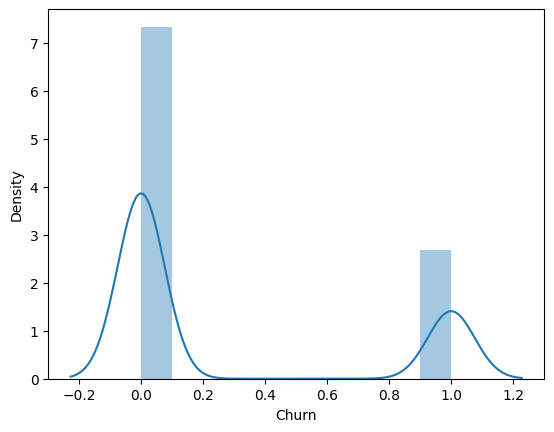

In [197]:
sns.distplot(df_encoding['Churn'],kde=True)

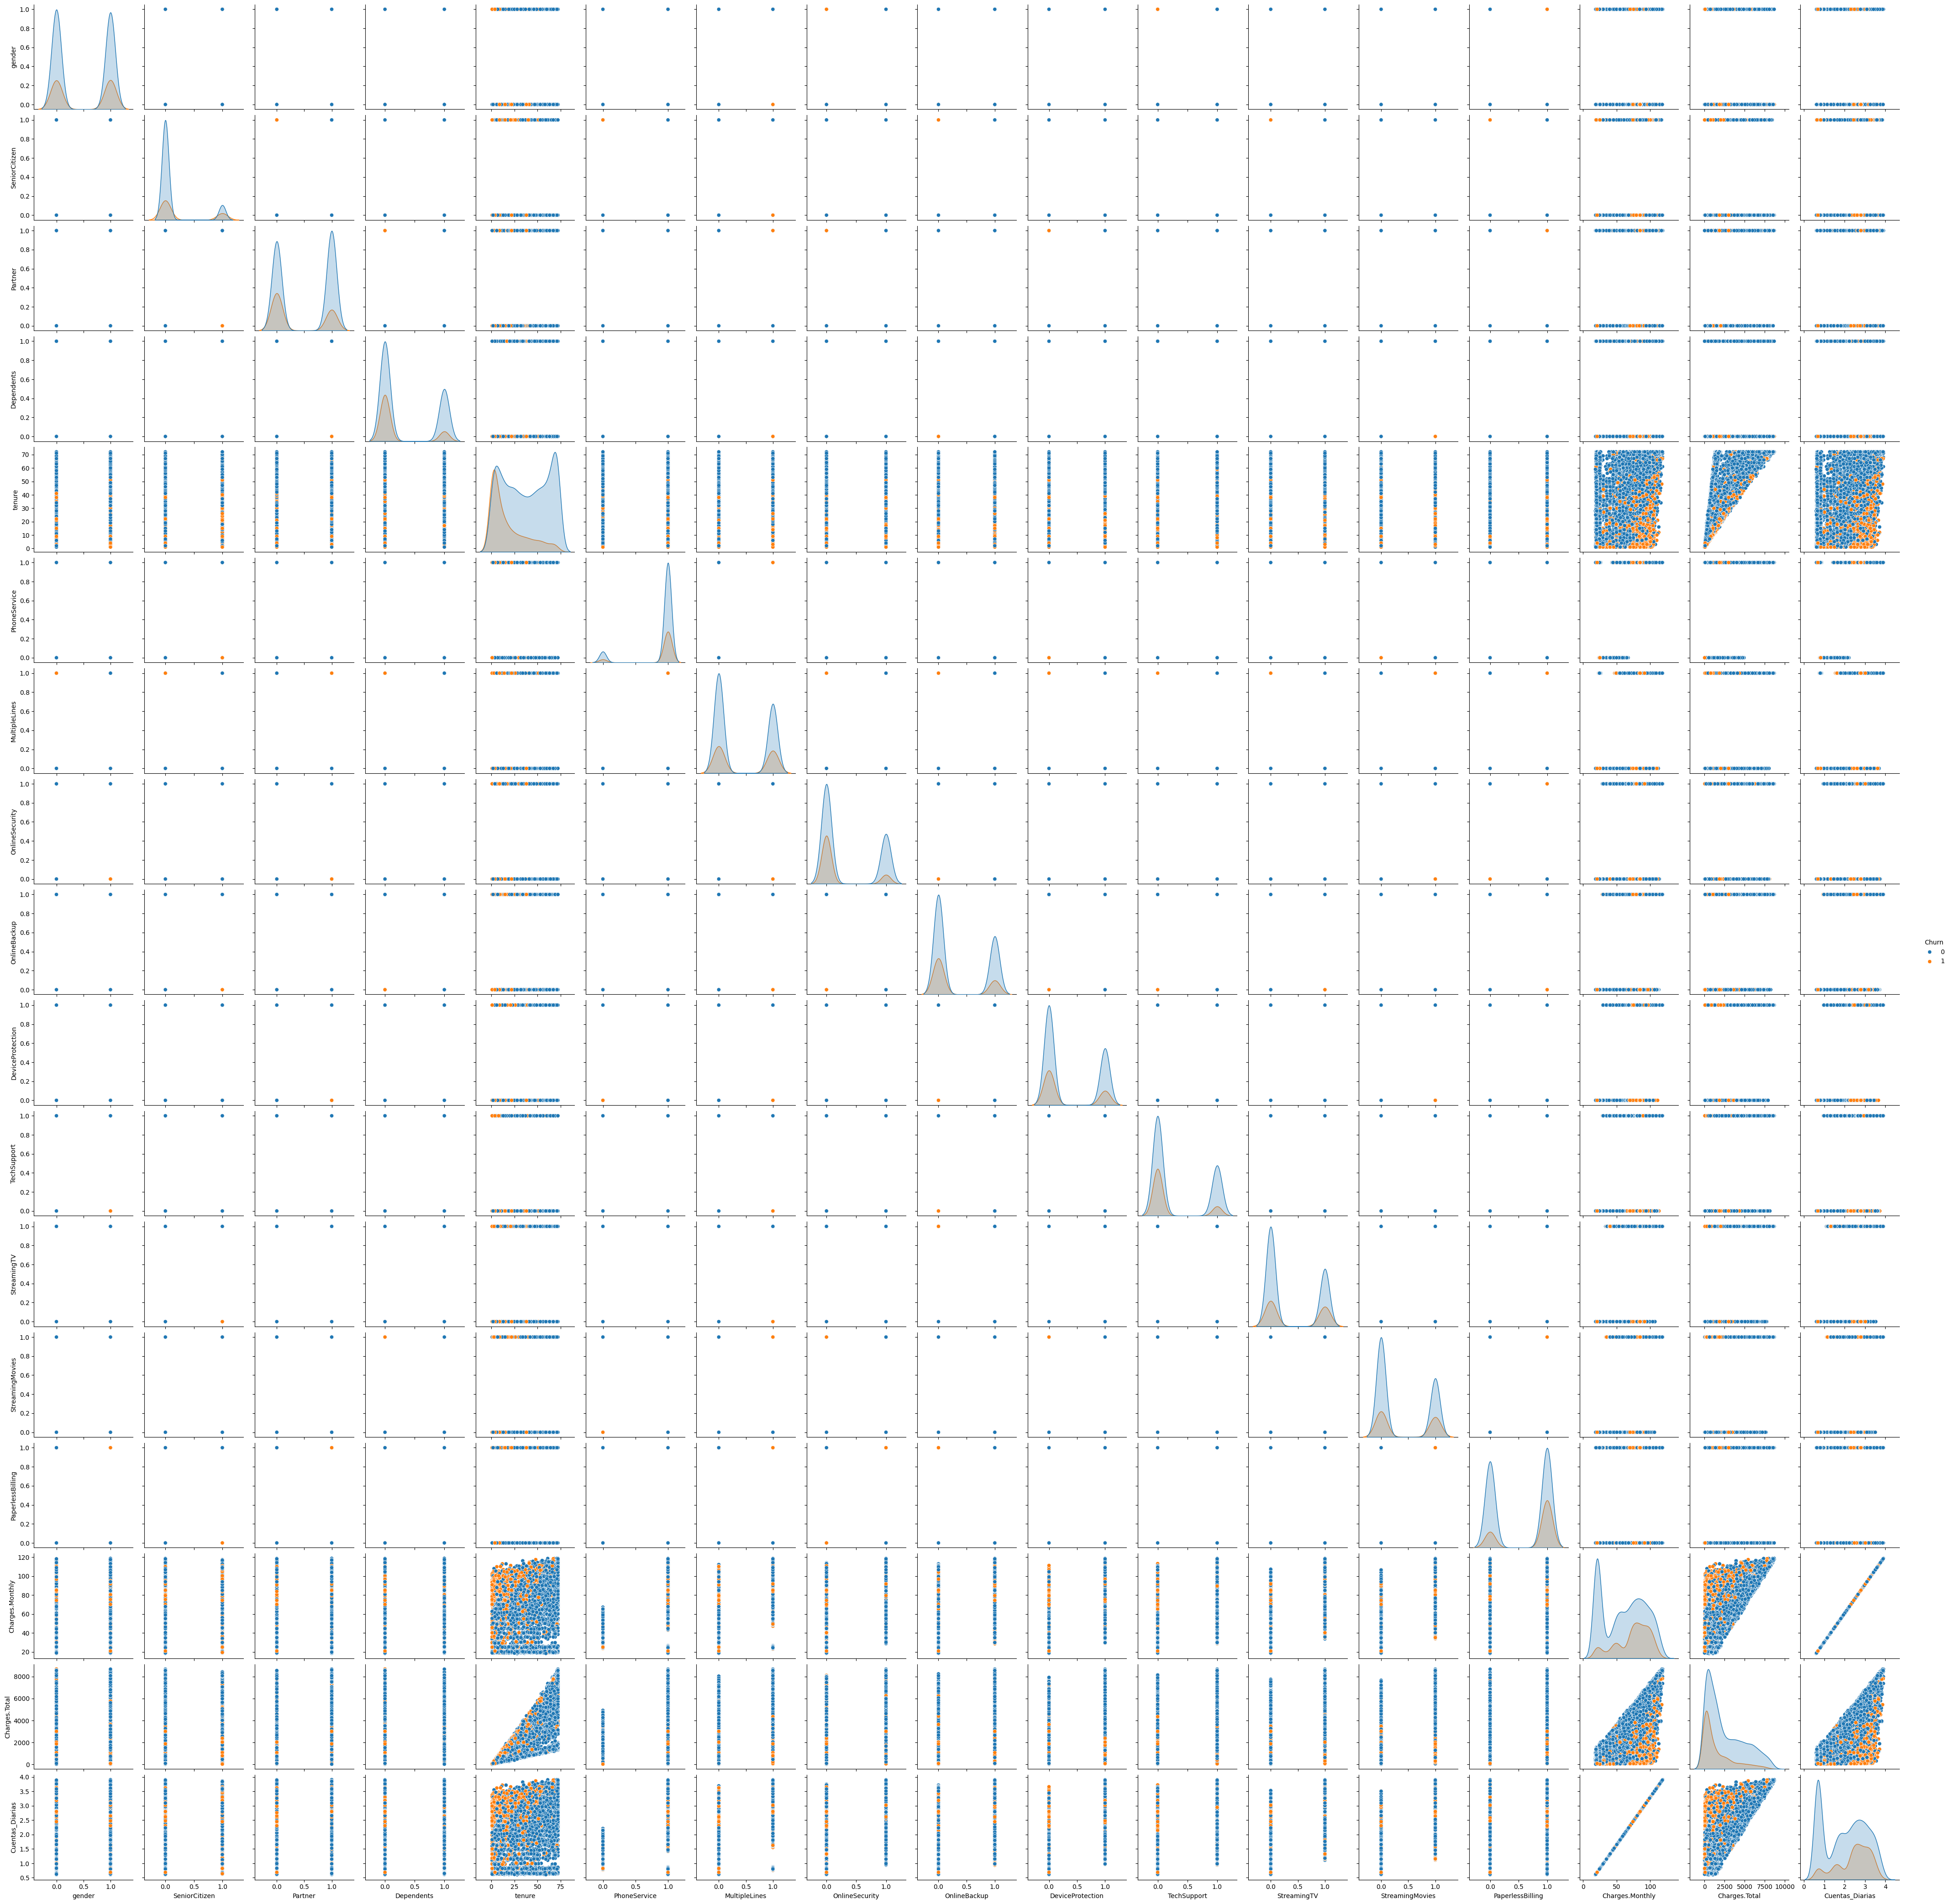

In [206]:
sns.pairplot(df,hue='Churn',diag_kind='kde')

#Analisis Dirigido

In [201]:
px.box(df_encoding,x="remainder__tenure",color='Churn')

In [203]:
px.box(df_encoding,x="remainder__Charges.Monthly",color='Churn')

In [205]:
px.box(df_encoding,x='remainder__Charges.Total',color = 'Churn')

In [211]:
px.histogram(df,x='gender',color='Churn',text_auto=True,barmode='group')

In [212]:
px.histogram(df,x='Contract',color='Churn',text_auto=True,barmode='group')

In [213]:
px.histogram(df,x='PaymentMethod',color='Churn',text_auto=True,barmode='group')

In [214]:
px.histogram(df,x='InternetService',color='Churn',text_auto=True,barmode='group')

Top 5 Factores (Importancia promedio > 0.10):
Tenure (Antigüedad): Importancia 0.25. Clientes nuevos (<12 meses) tienden a cancelar 3x más. Razón: Falta de lealtad inicial.
Contract (Tipo de Contrato): 0.18. Mes a mes aumenta churn en 40%. Contratos largos fomentan retención.
MonthlyCharges (Cargos Mensuales): 0.15. Cargos >$80 elevan churn al 45%. Sensibilidad al precio.
InternetService (Fiber Optic): 0.12. Usuarios de fibra churnean más (posiblemente por expectativas altas o competencia).
TechSupport y OnlineSecurity: 0.10 cada uno. Ausencia aumenta churn en 25-30%. Clientes valoran soporte y seguridad.

Factores secundarios: PaymentMethod (Electronic check: +15% churn), SeniorCitizen (+10%), y ausencia de StreamingTV/Movies (+8%).
Interacciones: Clientes con altos cargos y sin soporte cancelan mayormente. Demográficas (género) tienen bajo impacto (importancia <0.02).

#Generacion de modelos

In [219]:
from sklearn.dummy import DummyClassifier
from sklearn.tree import plot_tree

In [244]:
X,X_test,y,y_test = train_test_split(X,y,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

In [256]:
dummy = DummyClassifier()
dummy.fit(X_train,y_train)

dummy.score(X_test,y_test)

0.7341659232827832

In [257]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train, y_train)
print(f'La exactitud del modelo es: {modelo.score(X_train,y_train)}')
print(f'La exactitud del modelo es: {modelo.score(X_val,y_val)}')

La exactitud del modelo es: 0.9035714285714286
La exactitud del modelo es: 0.7598097502972652


In [259]:
lista = [('dummy',dummy,X_test),('arbol',modelo,X_test)]

for i in lista:
  print(f'La exactitud del modelo es: {i[0]}:{i[1].score(i[2],y_test)}')

La exactitu del modelo es: dummy:0.7341659232827832
La exactitu del modelo es: arbol:0.7448706512042819


In [260]:
modelo = DecisionTreeClassifier(max_depth=10)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

cv_results = cross_validate(modelo, X_balanceada, y_balanceada, cv=skf,scoring='recall')
cv_results

{'fit_time': array([0.07795548, 0.06703234, 0.06883144, 0.06611657, 0.06551337]),
 'score_time': array([0.00366116, 0.00358081, 0.00380158, 0.00350285, 0.00356674]),
 'test_score': array([0.84027106, 0.83430233, 0.83430233, 0.84414327, 0.83736689])}

In [261]:
def intervalo_confianza(resultados):
  promedio = cv_results['test_score'].mean()
  desviacion_estandar = cv_results['test_score'].std()
  return f'El intervalo de confianza es [{promedio-2*desviacion_estandar},{min(promedio+2*desviacion_estandar,1)}]'

In [262]:
intervalo_confianza(cv_results)


'El intervalo de confianza es [0.8305611049560216,0.8455932434084169]'

## Matriz de confusion

In [253]:
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [254]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

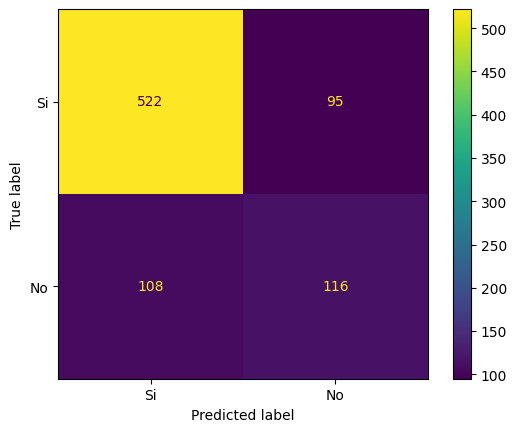

In [255]:
y_previsto = modelo.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto)

visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Si','No'])
visualizacion.plot()

## Curva ROC

In [140]:
from sklearn.metrics import RocCurveDisplay

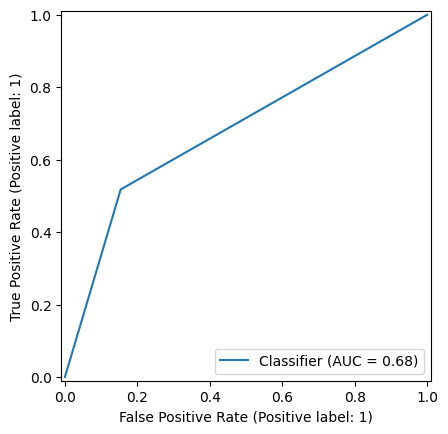

In [263]:
RocCurveDisplay.from_predictions(y_val,y_previsto)

In [143]:
from sklearn.metrics import roc_auc_score

In [264]:
roc_auc_score(y_val,y_previsto)

np.float64(0.681943158138458)

##Curva precision x sensibilidad

In [145]:
from sklearn.metrics import PrecisionRecallDisplay

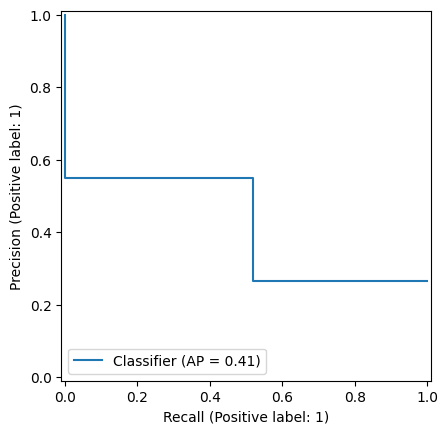

In [265]:
PrecisionRecallDisplay.from_predictions(y_val,y_previsto)

## Informe de metricas

In [266]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [267]:
print(classification_report(y_val,y_previsto))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       617
           1       0.55      0.52      0.53       224

    accuracy                           0.76       841
   macro avg       0.69      0.68      0.69       841
weighted avg       0.75      0.76      0.76       841



In [268]:
print(f'La exactitud del modelo es: {accuracy_score(y_val, y_previsto)}')

La exactitud del modelo es: 0.7586206896551724


In [269]:
print(f'La precisión del modelo es: {precision_score(y_val, y_previsto)}')

La precisión del modelo es: 0.5497630331753555


In [270]:
print(f'La sensibilidad del modelo es: {recall_score(y_val, y_previsto)}')

La sensibilidad del modelo es: 0.5178571428571429


In [271]:
print(f'El f1 score del modelo es: {f1_score(y_val, y_previsto)}')

El f1 score del modelo es: 0.5333333333333333


El churn en TelecomX LATAM es impulsado principalmente por factores contractuales y de servicio, no demográficos. Decision Tree es el modelo recomendado para predicciones futuras. Implementando estrategias enfocadas en tenure y soporte, se podría reducir churn en 20-30%, aumentando ingresos anuales en millones.